In [4]:
import torch
import json
import datasets as hf_datasets
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

from custom_datasets.qm9 import QM9Dataset
from utils.tokenizer import VocabTokenizer
from visualize_dataset import plot_molecule

/home/krojas/Documents/Research/Variable-Length-Diffusion/Variable-Length-Diffusion-Toy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
tokenizer = VocabTokenizer(vocab={'H', 'C', 'N', 'O', 'F'})

In [9]:
qm9_dataset = QM9Dataset(tokenizer)

for i in range(100):
    idx = np.random.randint(0, len(qm9_dataset))
    elem = qm9_dataset[idx]
    print(tokenizer.decode(elem['y']))
    print('--------------------------------')


HHHCCHHCNHHCCHHHCCHC
--------------------------------
HHHCCHCHCHCCFN
--------------------------------
HHHCHCHCHHCCOCN
--------------------------------
HHHCCHHCCHCHCHOHCHO
--------------------------------
OCHNHCHHCNHHCHHCC
--------------------------------
HHHCCOHCHHCOCHHHCHC
--------------------------------
HHHCHCNHHCHCHOCHCO
--------------------------------
HHNCHCCHOCHNCHC
--------------------------------
HHHCHHCHCHCHHCHCHCHO
--------------------------------
HHHCCCHHCHHCHHCNHCN
--------------------------------
HHHCCCHCHCHOHCCHC
--------------------------------
HHNCCOHHCOCNHN
--------------------------------
HHHCCHCHCHCHOCHHHCHHC
--------------------------------
HHHCHHCHHCHHCHHCHHCHCHHHCHO
--------------------------------
HHHCCHHHCHOHHCHHCOHCO
--------------------------------
FCFFCCCN
--------------------------------
HHCHCOHCHCHHCHCHCHC
--------------------------------
HOHCHCHHCOCOCN
--------------------------------
HHHCCHNHCHCHCOCHN
--------------------------------
OCHHCNHCHNHCCN
-----

In [ ]:
max_atoms_for_plot = 8
fixed_rotation_seed = 7

raw_qm9 = qm9_dataset.qm9_dataset
candidate_indices = [
    i for i in range(len(raw_qm9))
    if len(raw_qm9[i]['original_atomic_symbols']) <= max_atoms_for_plot
]
if len(candidate_indices) == 0:
    raise ValueError(f'No QM9 sample found with <= {max_atoms_for_plot} atoms.')

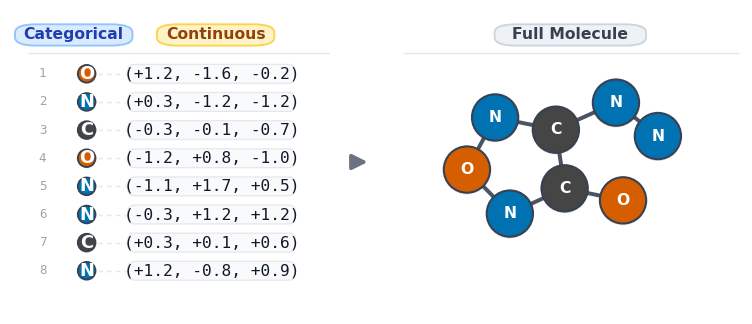

Saved to figures/qm9_multimodal_representation_95.[png|pdf]
Reproducible: sample_idx=21457, fixed_rotation_seed=13


In [ ]:
from pathlib import Path
from matplotlib.patches import FancyBboxPatch, Circle
from matplotlib.lines import Line2D
from visualize_dataset import _get_bonds_via_openbabel

# ── Gray palette (Material Design–style) ──
G50 = '#F9FAFB'
G200 = '#E5E7EB'
G400 = '#9CA3AF'
G500 = '#6B7280'
G700 = '#374151'
G900 = '#111827'

# ── Colorblind-safe palette (Wong 2011 adapted) ──
ATOM_CLR = {
    'H': '#999999',
    'C': '#454545',
    'N': '#0072B2',
    'O': '#D55E00',
    'F': '#009E73',
    'S': '#F0E442',
    'Cl': '#56B4E9',
    'P': '#E69F00',
    'Br': '#CC79A7',
}
ATOM_SZ = {
    'H': 160, 'C': 380, 'N': 380, 'O': 380, 'F': 380,
    'S': 480, 'Cl': 480, 'P': 480, 'Br': 480,
}
ATOM_R3D = {
    'H': 0.13, 'C': 0.20, 'N': 0.20, 'O': 0.20, 'F': 0.20,
    'S': 0.23, 'Cl': 0.23, 'P': 0.23, 'Br': 0.25,
}


def _tc(hex_c):
    c = hex_c.lstrip('#')
    lum = 0.299 * int(c[:2], 16) + 0.587 * int(c[2:4], 16) + 0.114 * int(c[4:6], 16)
    return '#FFFFFF' if lum < 140 else '#111111'


def _compute_row_positions(n, target_row_step=0.105, y_bottom=0.13, y_top_cap=0.80):
    if n == 1:
        return np.array([0.46])
    row_step = target_row_step
    y_top = y_bottom + row_step * (n - 1)
    if y_top > y_top_cap:
        row_step = (y_top_cap - y_bottom) / (n - 1)
        y_top = y_top_cap
    return np.array([y_top - i * row_step for i in range(n)])


def plot_qm9_multimodal_representation(
    *,
    raw_sample=None,
    symbols=None,
    positions=None,
    sample_idx=None,
    fixed_rotation_seed=13,
    out_stem='figures/qm9_multimodal_representation',
    save_formats=('png', 'pdf'),
    figsize=(5.0, 2.0),
    dpi=300,
    show=True,
    save=True,
    pad_inches=0.005,
    view_elev=5,
    view_azim=35,
    molecule_spread=1.16,
    atom_size_scale=1.3,
    bond_linewidth=1.9,
    target_row_step=0.105,
    y_bottom=0.22,
    y_top_cap=0.80,
):
    """Create multimodal token + 3D molecule figure from one molecule."""
    if raw_sample is not None:
        symbols = list(raw_sample['original_atomic_symbols'])
        positions = np.array(raw_sample['original_pos'], dtype=float)
    elif symbols is None or positions is None:
        raise ValueError('Provide either raw_sample OR both symbols and positions.')
    else:
        symbols = list(symbols)
        positions = np.array(positions, dtype=float)

    positions = positions.copy()
    positions -= positions.mean(axis=0, keepdims=True)

    rng = np.random.default_rng(fixed_rotation_seed)
    q, _ = np.linalg.qr(rng.standard_normal((3, 3)))
    if np.linalg.det(q) < 0:
        q[:, -1] *= -1
    positions = positions @ q

    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    })

    fig = plt.figure(figsize=figsize, facecolor='white', dpi=150)
    ax_tok = fig.add_axes([0.002, 0.0, 0.445, 0.98])
    ax_arr = fig.add_axes([0.447, 0.0, 0.033, 0.98])
    ax_mol = fig.add_axes([0.480, 0.0, 0.518, 0.98], projection='3d')

    # PANEL A — Multimodal token stream
    ax_tok.set_xlim(0, 1)
    ax_tok.set_ylim(0, 1)
    ax_tok.set_aspect('equal')
    ax_tok.axis('off')

    # Left pane keeps only top modality badges and divider (no bottom title).
    # Draw all top badges in figure coordinates for exact vertical alignment.

    tok_x0, tok_w = 0.002, 0.445
    cat_center_tok, cont_center_tok = 0.22, 0.68
    cat_w_tok, cont_w_tok = 0.325, 0.325

    # Align all three badges by their top edge
    top_badge_h_fig = 0.059
    top_badge_top_fig = 0.943
    top_badge_y_fig = top_badge_top_fig - top_badge_h_fig

    cat_center_fig = tok_x0 + tok_w * cat_center_tok
    cont_center_fig = tok_x0 + tok_w * cont_center_tok
    cat_w_fig = tok_w * cat_w_tok
    cont_w_fig = tok_w * cont_w_tok

    cat_badge = FancyBboxPatch(
        (cat_center_fig - cat_w_fig / 2, top_badge_y_fig), cat_w_fig, top_badge_h_fig,
        boxstyle='round,pad=0.006,rounding_size=0.028',
        facecolor='#DBEAFE', edgecolor='#93C5FD', linewidth=0.9,
        transform=fig.transFigure,
        clip_on=False,
    )
    fig.patches.append(cat_badge)
    fig.text(cat_center_fig, top_badge_y_fig + top_badge_h_fig / 2, 'Categorical', fontsize=7.5, fontweight='semibold',
             color='#1E40AF', ha='center', va='center')

    cont_badge = FancyBboxPatch(
        (cont_center_fig - cont_w_fig / 2, top_badge_y_fig), cont_w_fig, top_badge_h_fig,
        boxstyle='round,pad=0.006,rounding_size=0.028',
        facecolor='#FEF3C7', edgecolor='#FCD34D', linewidth=0.9,
        transform=fig.transFigure,
        clip_on=False,
    )
    fig.patches.append(cont_badge)
    fig.text(cont_center_fig, top_badge_y_fig + top_badge_h_fig / 2, 'Continuous', fontsize=7.5, fontweight='semibold',
             color='#92400E', ha='center', va='center')

    # Single divider y in figure coords so left and right dividers align
    divider_y_fig = 0.00 + 0.872 * 0.98
    fig.add_artist(Line2D([tok_x0 + 0.04 * tok_w, tok_x0 + 0.94 * tok_w], [divider_y_fig, divider_y_fig],
                         transform=fig.transFigure, color='#E5E7EB', linewidth=0.7, solid_capstyle='round'))

    max_display = 5
    n_display = min(max_display, len(symbols))
    n_rows = n_display + (1 if len(symbols) > max_display else 0)
    ys = _compute_row_positions(
        n_rows,
        target_row_step=target_row_step,
        y_bottom=y_bottom,
        y_top_cap=y_top_cap,
    )

    for i, (sym, y) in enumerate(zip(symbols[:n_display], ys[:n_display])):
        fc = ATOM_CLR.get(sym, '#888888')
        tc = _tc(fc)
        xi, yi, zi = positions[i]

        ax_tok.text(0.025, y, str(i + 1), fontsize=6, color=G400,
                    ha='center', va='center', family='monospace')

        circ = Circle((0.22, y), 0.030, linewidth=0.9, edgecolor=G700, facecolor=fc,
                      transform=ax_tok.transAxes, zorder=3)
        ax_tok.add_patch(circ)
        ax_tok.text(0.22, y, sym, fontsize=8.5, fontweight='bold', color=tc,
                    ha='center', va='center', zorder=4)

        ax_tok.plot([0.26, 0.36], [y, y], color=G200, lw=0.7, ls=(0, (3, 3)))

        pill = FancyBboxPatch((0.37, y - 0.027), 0.56, 0.054,
                              boxstyle='round,pad=0.005,rounding_size=0.024',
                              facecolor=G50, edgecolor=G200, linewidth=0.6,
                              transform=ax_tok.transAxes, zorder=2)
        ax_tok.add_patch(pill)
        ax_tok.text(0.68, y, f'({xi:+.1f}, {yi:+.1f}, {zi:+.1f})',
                    fontsize=7.8, family='monospace', color=G900,
                    ha='center', va='center', zorder=3)

    if len(symbols) > max_display:
        y_ellipsis = ys[n_display]
        ax_tok.text(0.68, y_ellipsis, '...', fontsize=9, color=G500,
                    ha='center', va='center', zorder=3)

    # CONNECTOR
    ax_arr.set_xlim(0, 1)
    ax_arr.set_ylim(0, 1)
    ax_arr.axis('off')
    ax_arr.annotate('', xy=(0.92, 0.5), xytext=(0.08, 0.5),
                    arrowprops=dict(arrowstyle='-|>', lw=1.8, mutation_scale=15, color=G500))

    # PANEL B — 3D molecular geometry
    ax_mol.set_facecolor('white')

    # Right badge uses the same figure-level y-band as left badges.
    full_center = 0.742
    full_w = 0.19
    full_badge = FancyBboxPatch(
        (full_center - full_w / 2, top_badge_y_fig), full_w, top_badge_h_fig,
        boxstyle='round,pad=0.006,rounding_size=0.028',
        facecolor='#EEF2F7', edgecolor='#CBD5E1', linewidth=0.9,
        transform=fig.transFigure,
        clip_on=False,
    )
    fig.patches.append(full_badge)
    fig.text(full_center, top_badge_y_fig + top_badge_h_fig / 2, 'Full Molecule', fontsize=7.5, fontweight='semibold',
             color=G700, ha='center', va='center')

    fig.add_artist(Line2D([0.52, 0.965], [divider_y_fig, divider_y_fig], transform=fig.transFigure,
                          color='#E5E7EB', linewidth=0.7, solid_capstyle='round'))

    # Slightly expand the geometry and reduce marker scale to avoid visual stacking.
    pos_plot = positions.copy() * molecule_spread
    colors_3d = [ATOM_CLR.get(s, '#888') for s in symbols]
    sizes_3d = np.array([ATOM_SZ.get(s, 300) for s in symbols], dtype=float) * atom_size_scale

    bonds = _get_bonds_via_openbabel(symbols, pos_plot)
    for bi, bj in bonds:
        pi, pj = pos_plot[bi], pos_plot[bj]
        v = pj - pi
        d = np.linalg.norm(v)
        if d < 1e-8:
            continue
        u = v / d
        start = pi + u * ATOM_R3D.get(symbols[bi], 0.18)
        end = pj - u * ATOM_R3D.get(symbols[bj], 0.18)
        if np.linalg.norm(end - start) < 1e-4:
            continue
        ax_mol.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]],
                    color=G700, linewidth=bond_linewidth, solid_capstyle='round', alpha=0.9, zorder=2)

    ax_mol.scatter(pos_plot[:, 0] - 0.015, pos_plot[:, 1] - 0.015, pos_plot[:, 2] - 0.03,
                   s=sizes_3d * 1.06, c='#111827', alpha=0.10,
                   linewidths=0, depthshade=False, zorder=1)
    ax_mol.scatter(pos_plot[:, 0], pos_plot[:, 1], pos_plot[:, 2],
                   s=sizes_3d, c=colors_3d, edgecolor=G700, linewidths=1.0,
                   alpha=1.0, depthshade=True, zorder=4)
    ax_mol.scatter(pos_plot[:, 0] - 0.020, pos_plot[:, 1] + 0.018, pos_plot[:, 2] + 0.022,
                   s=sizes_3d * 0.16, c='white', alpha=0.34,
                   linewidths=0, depthshade=False, zorder=5)

    for i, sym in enumerate(symbols):
        ax_mol.text(pos_plot[i, 0], pos_plot[i, 1], pos_plot[i, 2], sym,
                    fontsize=7.5, ha='center', va='center', zorder=6,
                    color=_tc(ATOM_CLR.get(sym, '#888')), fontweight='bold')

    mins, maxs = pos_plot.min(axis=0), pos_plot.max(axis=0)
    ctr = (mins + maxs) / 2.0
    hr = max((maxs - mins).max() / 2.0 + 0.24, 0.78)
    ax_mol.set_xlim(ctr[0] - 1.18 * hr, ctr[0] + 0.82 * hr)
    ax_mol.set_ylim(ctr[1] - hr, ctr[1] + hr)
    ax_mol.set_zlim(ctr[2] - hr, ctr[2] + hr)
    ax_mol.set_box_aspect((1, 1, 1))
    ax_mol.set_proj_type('persp')
    ax_mol.view_init(elev=view_elev, azim=view_azim)

    ax_mol.grid(False)
    ax_mol.set_xticks([])
    ax_mol.set_yticks([])
    ax_mol.set_zticks([])
    for axis in (ax_mol.xaxis, ax_mol.yaxis, ax_mol.zaxis):
        axis.pane.set_edgecolor((0, 0, 0, 0))
        axis.pane.set_facecolor((1, 1, 1, 0))
    ax_mol.set_axis_off()

    out_paths = []
    if save:
        for fmt in save_formats:
            out = Path(f'{out_stem}.{fmt}')
            out.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white', pad_inches=pad_inches)
            out_paths.append(out)

    if show:
        plt.show()

    return {
        'fig': fig,
        'axes': {'tokens': ax_tok, 'arrow': ax_arr, 'molecule': ax_mol},
        'out_paths': out_paths,
        'sample_idx': sample_idx,
        'fixed_rotation_seed': fixed_rotation_seed,
    }


# Example usage
for i in list([95]):
    sample_idx = candidate_indices[i]
    raw_sample = raw_qm9[sample_idx]
    fixed_rotation_seed = 13

    result = plot_qm9_multimodal_representation(
        raw_sample=raw_sample,
        sample_idx=sample_idx,
        fixed_rotation_seed=fixed_rotation_seed,
    )

    if result['out_paths']:
        stem = result['out_paths'][0].with_suffix('')
        stem = f'{stem}_{i}'
        formats = '|'.join(p.suffix.lstrip('.') for p in result['out_paths'])
        print(f'Saved to {stem}.[{formats}]')
    print(f'Reproducible: sample_idx={sample_idx}, fixed_rotation_seed={fixed_rotation_seed}')

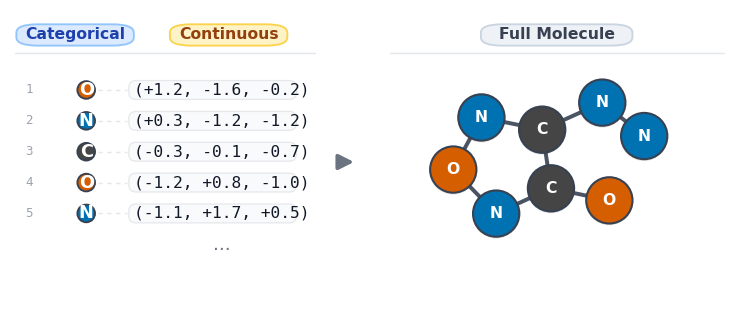

Saved to figures/qm9_multimodal_representation_95.[png|pdf]
Reproducible: sample_idx=21457, fixed_rotation_seed=13


In [ ]:
from pathlib import Path
from matplotlib.patches import FancyBboxPatch, Circle
from matplotlib.lines import Line2D
from visualize_dataset import _get_bonds_via_openbabel

# ── Gray palette (Material Design–style) ──
G50 = '#F9FAFB'
G200 = '#E5E7EB'
G400 = '#9CA3AF'
G500 = '#6B7280'
G700 = '#374151'
G900 = '#111827'

# ── Colorblind-safe palette (Wong 2011 adapted) ──
ATOM_CLR = {
    'H': '#999999',
    'C': '#454545',
    'N': '#0072B2',
    'O': '#D55E00',
    'F': '#009E73',
    'S': '#F0E442',
    'Cl': '#56B4E9',
    'P': '#E69F00',
    'Br': '#CC79A7',
}
ATOM_SZ = {
    'H': 160, 'C': 380, 'N': 380, 'O': 380, 'F': 380,
    'S': 480, 'Cl': 480, 'P': 480, 'Br': 480,
}
ATOM_R3D = {
    'H': 0.13, 'C': 0.20, 'N': 0.20, 'O': 0.20, 'F': 0.20,
    'S': 0.23, 'Cl': 0.23, 'P': 0.23, 'Br': 0.25,
}


def _tc(hex_c):
    c = hex_c.lstrip('#')
    lum = 0.299 * int(c[:2], 16) + 0.587 * int(c[2:4], 16) + 0.114 * int(c[4:6], 16)
    return '#FFFFFF' if lum < 140 else '#111111'


def _compute_row_positions(n, target_row_step=0.105, y_bottom=0.13, y_top_cap=0.80):
    if n == 1:
        return np.array([0.46])
    row_step = target_row_step
    y_top = y_bottom + row_step * (n - 1)
    if y_top > y_top_cap:
        row_step = (y_top_cap - y_bottom) / (n - 1)
        y_top = y_top_cap
    return np.array([y_top - i * row_step for i in range(n)])


def plot_qm9_multimodal_representation(
    *,
    raw_sample=None,
    symbols=None,
    positions=None,
    sample_idx=None,
    fixed_rotation_seed=13,
    out_stem='figures/qm9_multimodal_representation',
    save_formats=('png', 'pdf'),
    figsize=(5.0, 2.0),
    dpi=300,
    show=True,
    save=True,
    pad_inches=0.005,
    view_elev=5,
    view_azim=35,
    molecule_spread=1.16,
    atom_size_scale=1.3,
    bond_linewidth=1.9,
    target_row_step=0.105,
    y_bottom=0.22,
    y_top_cap=0.80,
):
    """Create multimodal token + 3D molecule figure from one molecule."""
    if raw_sample is not None:
        symbols = list(raw_sample['original_atomic_symbols'])
        positions = np.array(raw_sample['original_pos'], dtype=float)
    elif symbols is None or positions is None:
        raise ValueError('Provide either raw_sample OR both symbols and positions.')
    else:
        symbols = list(symbols)
        positions = np.array(positions, dtype=float)

    positions = positions.copy()
    positions -= positions.mean(axis=0, keepdims=True)

    rng = np.random.default_rng(fixed_rotation_seed)
    q, _ = np.linalg.qr(rng.standard_normal((3, 3)))
    if np.linalg.det(q) < 0:
        q[:, -1] *= -1
    positions = positions @ q

    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    })

    fig = plt.figure(figsize=figsize, facecolor='white', dpi=150)
    ax_tok = fig.add_axes([0.002, 0.0, 0.445, 0.98])
    ax_arr = fig.add_axes([0.447, 0.0, 0.033, 0.98])
    ax_mol = fig.add_axes([0.480, 0.0, 0.518, 0.98], projection='3d')

    # PANEL A — Multimodal token stream
    ax_tok.set_xlim(0, 1)
    ax_tok.set_ylim(0, 1)
    ax_tok.set_aspect('equal')
    ax_tok.axis('off')

    # Left pane keeps only top modality badges and divider (no bottom title).
    # Draw all top badges in figure coordinates for exact vertical alignment.

    tok_x0, tok_w = 0.002, 0.445
    cat_center_tok, cont_center_tok = 0.22, 0.68
    cat_w_tok, cont_w_tok = 0.325, 0.325

    # Align all three badges by their top edge
    top_badge_h_fig = 0.059
    top_badge_top_fig = 0.943
    top_badge_y_fig = top_badge_top_fig - top_badge_h_fig

    cat_center_fig = tok_x0 + tok_w * cat_center_tok
    cont_center_fig = tok_x0 + tok_w * cont_center_tok
    cat_w_fig = tok_w * cat_w_tok
    cont_w_fig = tok_w * cont_w_tok

    cat_badge = FancyBboxPatch(
        (cat_center_fig - cat_w_fig / 2, top_badge_y_fig), cat_w_fig, top_badge_h_fig,
        boxstyle='round,pad=0.006,rounding_size=0.028',
        facecolor='#DBEAFE', edgecolor='#93C5FD', linewidth=0.9,
        transform=fig.transFigure,
        clip_on=False,
    )
    fig.patches.append(cat_badge)
    fig.text(cat_center_fig, top_badge_y_fig + top_badge_h_fig / 2, 'Categorical', fontsize=7.5, fontweight='semibold',
             color='#1E40AF', ha='center', va='center')

    cont_badge = FancyBboxPatch(
        (cont_center_fig - cont_w_fig / 2, top_badge_y_fig), cont_w_fig, top_badge_h_fig,
        boxstyle='round,pad=0.006,rounding_size=0.028',
        facecolor='#FEF3C7', edgecolor='#FCD34D', linewidth=0.9,
        transform=fig.transFigure,
        clip_on=False,
    )
    fig.patches.append(cont_badge)
    fig.text(cont_center_fig, top_badge_y_fig + top_badge_h_fig / 2, 'Continuous', fontsize=7.5, fontweight='semibold',
             color='#92400E', ha='center', va='center')

    # Single divider y in figure coords so left and right dividers align
    divider_y_fig = 0.00 + 0.872 * 0.98
    fig.add_artist(Line2D([tok_x0 + 0.04 * tok_w, tok_x0 + 0.94 * tok_w], [divider_y_fig, divider_y_fig],
                         transform=fig.transFigure, color='#E5E7EB', linewidth=0.7, solid_capstyle='round'))

    max_display = 5
    n_display = min(max_display, len(symbols))
    n_rows = n_display + (1 if len(symbols) > max_display else 0)
    ys = _compute_row_positions(
        n_rows,
        target_row_step=target_row_step,
        y_bottom=y_bottom,
        y_top_cap=y_top_cap,
    )

    for i, (sym, y) in enumerate(zip(symbols[:n_display], ys[:n_display])):
        fc = ATOM_CLR.get(sym, '#888888')
        tc = _tc(fc)
        xi, yi, zi = positions[i]

        ax_tok.text(0.025, y, str(i + 1), fontsize=6, color=G400,
                    ha='center', va='center', family='monospace')

        circ = Circle((0.22, y), 0.030, linewidth=0.9, edgecolor=G700, facecolor=fc,
                      transform=ax_tok.transAxes, zorder=3)
        ax_tok.add_patch(circ)
        ax_tok.text(0.22, y, sym, fontsize=8.5, fontweight='bold', color=tc,
                    ha='center', va='center', zorder=4)

        ax_tok.plot([0.26, 0.36], [y, y], color=G200, lw=0.7, ls=(0, (3, 3)))

        pill = FancyBboxPatch((0.37, y - 0.027), 0.56, 0.054,
                              boxstyle='round,pad=0.005,rounding_size=0.024',
                              facecolor=G50, edgecolor=G200, linewidth=0.6,
                              transform=ax_tok.transAxes, zorder=2)
        ax_tok.add_patch(pill)
        ax_tok.text(0.68, y, f'({xi:+.1f}, {yi:+.1f}, {zi:+.1f})',
                    fontsize=7.8, family='monospace', color=G900,
                    ha='center', va='center', zorder=3)

    if len(symbols) > max_display:
        y_ellipsis = ys[n_display]
        ax_tok.text(0.68, y_ellipsis, '...', fontsize=9, color=G500,
                    ha='center', va='center', zorder=3)

    # CONNECTOR
    ax_arr.set_xlim(0, 1)
    ax_arr.set_ylim(0, 1)
    ax_arr.axis('off')
    ax_arr.annotate('', xy=(0.92, 0.5), xytext=(0.08, 0.5),
                    arrowprops=dict(arrowstyle='-|>', lw=1.8, mutation_scale=15, color=G500))

    # PANEL B — 3D molecular geometry
    ax_mol.set_facecolor('white')

    # Right badge uses the same figure-level y-band as left badges.
    full_center = 0.742
    full_w = 0.19
    full_badge = FancyBboxPatch(
        (full_center - full_w / 2, top_badge_y_fig), full_w, top_badge_h_fig,
        boxstyle='round,pad=0.006,rounding_size=0.028',
        facecolor='#EEF2F7', edgecolor='#CBD5E1', linewidth=0.9,
        transform=fig.transFigure,
        clip_on=False,
    )
    fig.patches.append(full_badge)
    fig.text(full_center, top_badge_y_fig + top_badge_h_fig / 2, 'Full Molecule', fontsize=7.5, fontweight='semibold',
             color=G700, ha='center', va='center')

    fig.add_artist(Line2D([0.52, 0.965], [divider_y_fig, divider_y_fig], transform=fig.transFigure,
                          color='#E5E7EB', linewidth=0.7, solid_capstyle='round'))

    # Slightly expand the geometry and reduce marker scale to avoid visual stacking.
    pos_plot = positions.copy() * molecule_spread
    colors_3d = [ATOM_CLR.get(s, '#888') for s in symbols]
    sizes_3d = np.array([ATOM_SZ.get(s, 300) for s in symbols], dtype=float) * atom_size_scale

    bonds = _get_bonds_via_openbabel(symbols, pos_plot)
    for bi, bj in bonds:
        pi, pj = pos_plot[bi], pos_plot[bj]
        v = pj - pi
        d = np.linalg.norm(v)
        if d < 1e-8:
            continue
        u = v / d
        start = pi + u * ATOM_R3D.get(symbols[bi], 0.18)
        end = pj - u * ATOM_R3D.get(symbols[bj], 0.18)
        if np.linalg.norm(end - start) < 1e-4:
            continue
        ax_mol.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]],
                    color=G700, linewidth=bond_linewidth, solid_capstyle='round', alpha=0.9, zorder=2)

    ax_mol.scatter(pos_plot[:, 0] - 0.015, pos_plot[:, 1] - 0.015, pos_plot[:, 2] - 0.03,
                   s=sizes_3d * 1.06, c='#111827', alpha=0.10,
                   linewidths=0, depthshade=False, zorder=1)
    ax_mol.scatter(pos_plot[:, 0], pos_plot[:, 1], pos_plot[:, 2],
                   s=sizes_3d, c=colors_3d, edgecolor=G700, linewidths=1.0,
                   alpha=1.0, depthshade=True, zorder=4)
    ax_mol.scatter(pos_plot[:, 0] - 0.020, pos_plot[:, 1] + 0.018, pos_plot[:, 2] + 0.022,
                   s=sizes_3d * 0.16, c='white', alpha=0.34,
                   linewidths=0, depthshade=False, zorder=5)

    for i, sym in enumerate(symbols):
        ax_mol.text(pos_plot[i, 0], pos_plot[i, 1], pos_plot[i, 2], sym,
                    fontsize=7.5, ha='center', va='center', zorder=6,
                    color=_tc(ATOM_CLR.get(sym, '#888')), fontweight='bold')

    mins, maxs = pos_plot.min(axis=0), pos_plot.max(axis=0)
    ctr = (mins + maxs) / 2.0
    hr = max((maxs - mins).max() / 2.0 + 0.24, 0.78)
    ax_mol.set_xlim(ctr[0] - 1.18 * hr, ctr[0] + 0.82 * hr)
    ax_mol.set_ylim(ctr[1] - hr, ctr[1] + hr)
    ax_mol.set_zlim(ctr[2] - hr, ctr[2] + hr)
    ax_mol.set_box_aspect((1, 1, 1))
    ax_mol.set_proj_type('persp')
    ax_mol.view_init(elev=view_elev, azim=view_azim)

    ax_mol.grid(False)
    ax_mol.set_xticks([])
    ax_mol.set_yticks([])
    ax_mol.set_zticks([])
    for axis in (ax_mol.xaxis, ax_mol.yaxis, ax_mol.zaxis):
        axis.pane.set_edgecolor((0, 0, 0, 0))
        axis.pane.set_facecolor((1, 1, 1, 0))
    ax_mol.set_axis_off()

    out_paths = []
    if save:
        for fmt in save_formats:
            out = Path(f'{out_stem}.{fmt}')
            out.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white', pad_inches=pad_inches)
            out_paths.append(out)

    if show:
        plt.show()

    return {
        'fig': fig,
        'axes': {'tokens': ax_tok, 'arrow': ax_arr, 'molecule': ax_mol},
        'out_paths': out_paths,
        'sample_idx': sample_idx,
        'fixed_rotation_seed': fixed_rotation_seed,
    }


# Example usage
for i in list([95]):
    sample_idx = candidate_indices[i]
    raw_sample = raw_qm9[sample_idx]
    fixed_rotation_seed = 13

    result = plot_qm9_multimodal_representation(
        raw_sample=raw_sample,
        sample_idx=sample_idx,
        fixed_rotation_seed=fixed_rotation_seed,
    )

    if result['out_paths']:
        stem = result['out_paths'][0].with_suffix('')
        stem = f'{stem}_{i}'
        formats = '|'.join(p.suffix.lstrip('.') for p in result['out_paths'])
        print(f'Saved to {stem}.[{formats}]')
    print(f'Reproducible: sample_idx={sample_idx}, fixed_rotation_seed={fixed_rotation_seed}')

In [ ]:
# Compare average KS statistic (all_samples) for Euler vs 2nd-order at checkpoint 1350
from pathlib import Path
import re
import matplotlib.pyplot as plt

results_root = Path("results")
checkpoint = "1350"

records = []
for run_dir in results_root.glob(f"results-matching-{checkpoint}-*"):
    name = run_dir.name
    # Use "split" folders as 2nd-order runs to match existing naming.
    if "euler" in name:
        method = "Euler"
    elif "split" in name:
        method = "2nd order"
    else:
        continue

    step_match = re.search(r"-(\d+)steps", name)
    if not step_match:
        continue
    steps = int(step_match.group(1))

    summary_path = run_dir / "all_samples" / "ks_statistics_summary.txt"
    if not summary_path.exists():
        continue

    lines = [line.strip() for line in summary_path.read_text().splitlines() if line.strip()]
    if not lines:
        continue

    last_line = lines[-1]  # expected like: "Average          0.9320"
    value_match = re.search(r"([0-9]*\.?[0-9]+)\s*$", last_line)
    if not value_match:
        continue
    avg_ks = float(value_match.group(1))

    records.append({"method": method, "steps": steps, "avg_ks": avg_ks, "run": name})

if not records:
    raise RuntimeError("No matching results found for checkpoint 1350.")

# Sort and print what was collected for transparency.
records = sorted(records, key=lambda r: (r["method"], r["steps"]))
for r in records:
    print(f"{r['method']:10s} | steps={r['steps']:4d} | avg={r['avg_ks']:.4f} | {r['run']}")

series = {"Euler": [], "2nd order": []}
for r in records:
    series[r["method"]].append((r["steps"], r["avg_ks"]))

plt.figure(figsize=(7, 4.5))
for method, pts in series.items():
    if not pts:
        continue
    x = [p[0] for p in pts]
    y = [p[1] for p in pts]
    plt.plot(x, y, marker="o", linewidth=2, label=method)

plt.xlabel("Sampling steps")
plt.ylabel("Average KS statistic (all_samples)")
plt.title("Checkpoint 1350: Euler vs 2nd order")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

RuntimeError: No matching results found for checkpoint 1350.

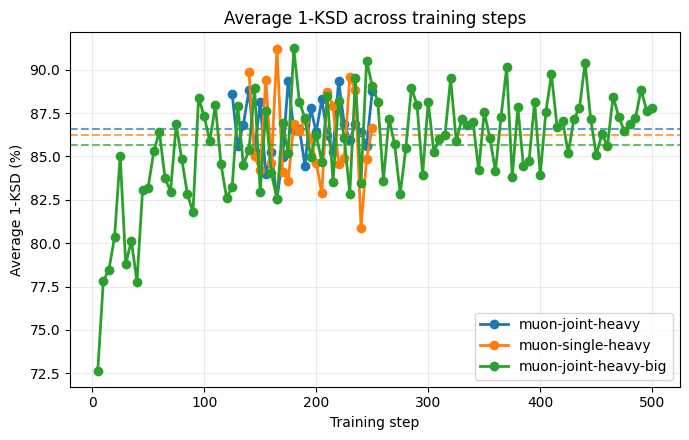

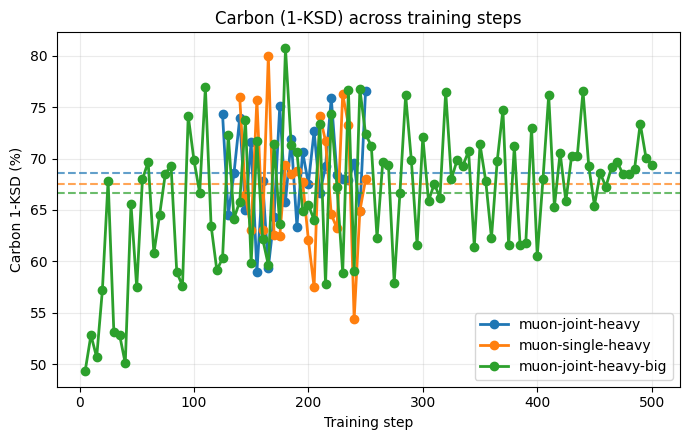

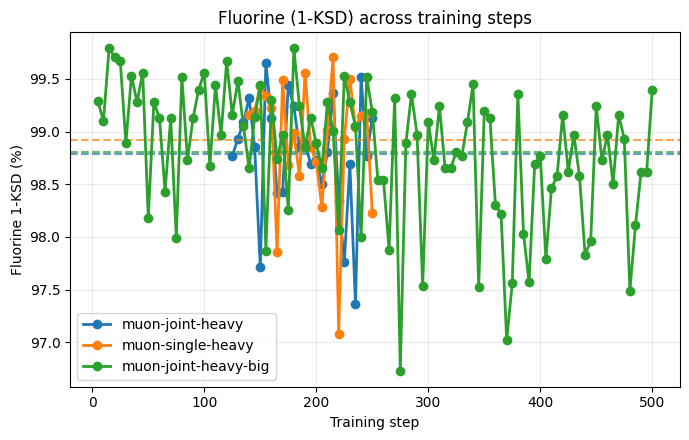

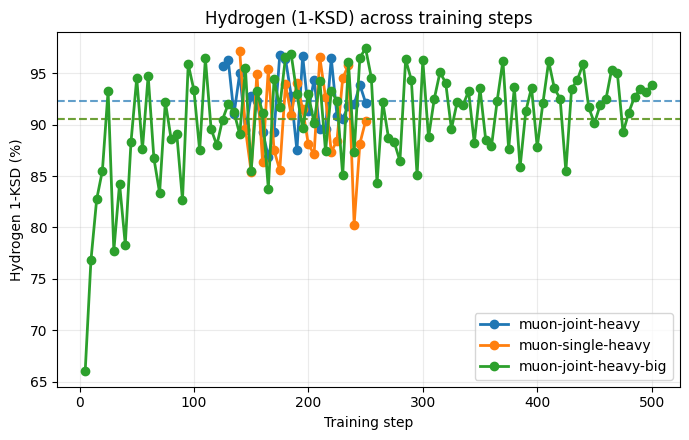

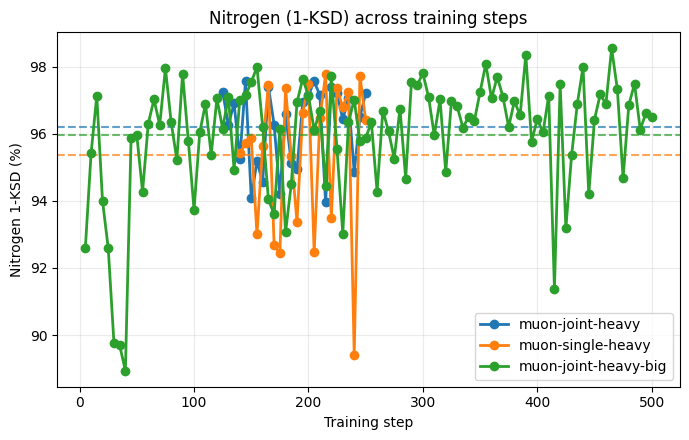

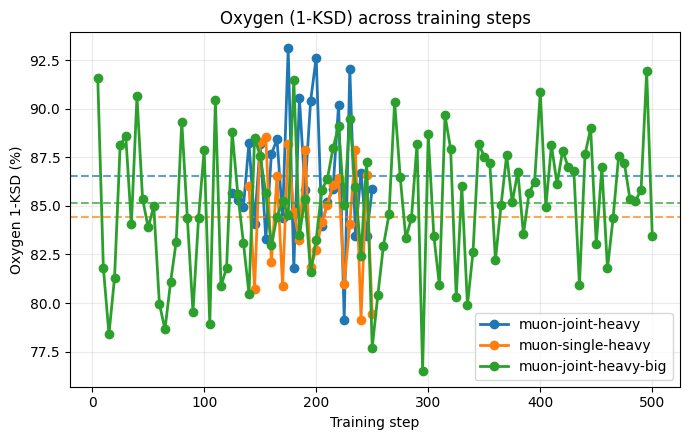

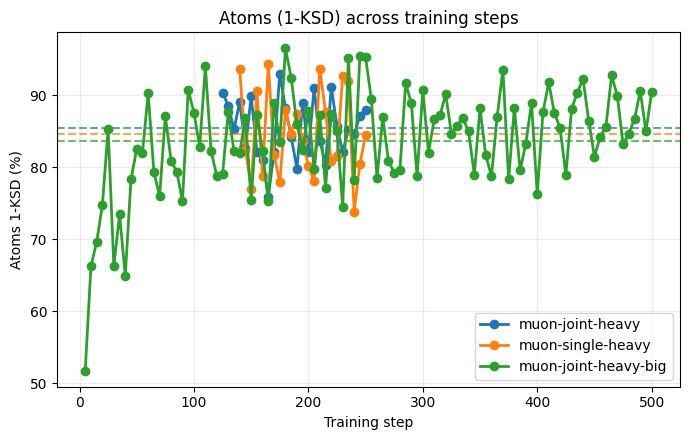

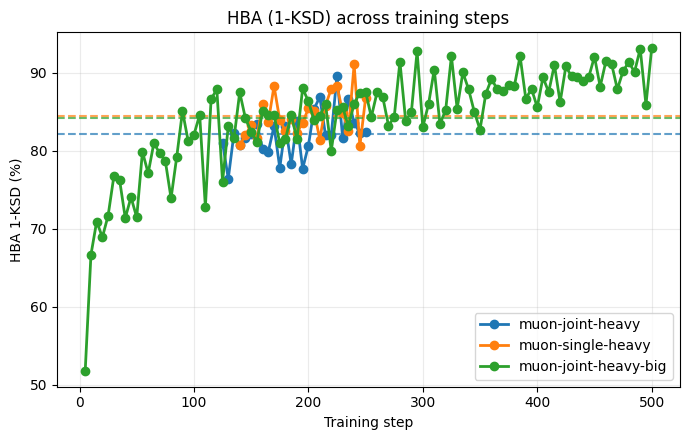

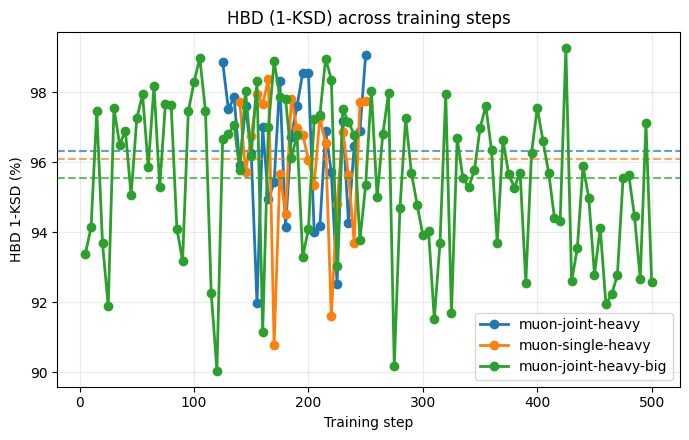

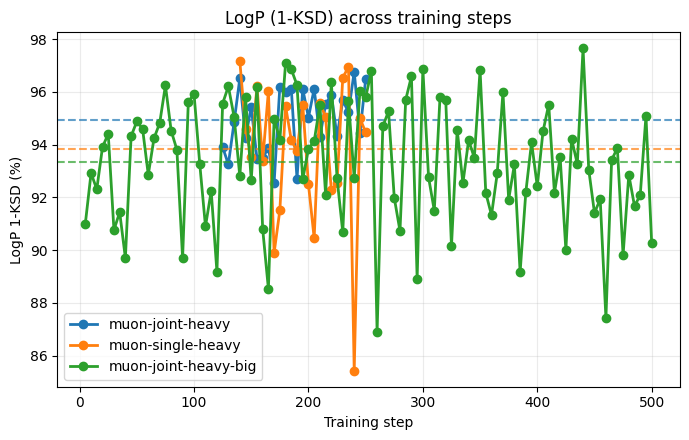

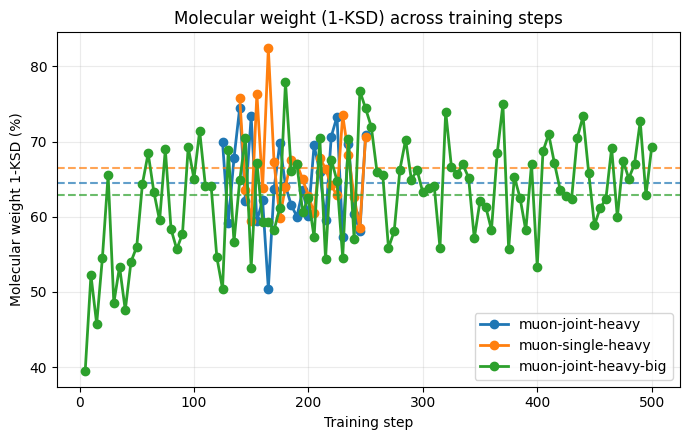

In [2]:
# Plot KS statistics across multiple result folders (e.g. results-muon-joint-heavy, results-muon-single-heavy)
from pathlib import Path
import re
import matplotlib.pyplot as plt

# Configure: list of result folder names (relative to project root)
RESULT_FOLDERS = [
    "results-muon-joint-heavy",
    "results-muon-single-heavy",
    # "results/qm9_sampling_grid"
    "results-muon-joint-heavy-big"
]

# Metric display names (optional prettification)
METRIC_LABELS = {
    "mw": "Molecular weight",
    "logp": "LogP",
    "hbd": "HBD",
    "hba": "HBA",
    "C": "Carbon",
    "H": "Hydrogen",
    "O": "Oxygen",
    "N": "Nitrogen",
    "F": "Fluorine",
    "atoms": "Atoms",
    "Average": "Average",
}


def parse_ks_summary(summary_path: Path) -> dict[str, float] | None:
    """Parse ks_statistics_summary.txt. Returns dict of metric -> 1-KSD value, or None if missing."""
    if not summary_path.exists():
        return None
    lines = summary_path.read_text().splitlines()
    result = {}
    for line in lines:
        line = line.strip()
        if not line or line.startswith("=") or line.startswith("-"):
            continue
        parts = line.split()
        if len(parts) >= 2:
            metric = parts[0]
            try:
                result[metric] = float(parts[1])
            except ValueError:
                pass
    return result if result else None


def folder_training_step(dirname: str) -> int | None:
    """Training step from dirname: itr_<n> or *step<n>* (e.g. qm9_gen_step315000_dt0p008)."""
    m = re.match(r"itr_(\d+)", dirname)
    if m:
        return int(m.group(1))
    m = re.search(r"step(\d+)", dirname)
    if m:
        return int(m.group(1))
    return None


def collect_folder_data(folder: Path) -> list[tuple[int, dict[str, float]]]:
    """Collect (training_step, metrics) per subfolder: itr_* or ckpt-style *step* (e.g. qm9_sampling_grid)."""
    rows = []
    for d in sorted(
        folder.iterdir(),
        key=lambda p: folder_training_step(p.name) or 0,
    ):
        if not d.is_dir():
            continue
        step = folder_training_step(d.name)
        if step is None:
            continue
        summary_path = d / "all_samples" / "ks_statistics_summary.txt"
        metrics = parse_ks_summary(summary_path)
        if metrics:
            rows.append((step, metrics))
    return rows


# Collect data from all folders
root = Path(".")
all_data: dict[str, list[tuple[int, dict[str, float]]]] = {}
for folder_name in RESULT_FOLDERS:
    folder = root / folder_name
    if not folder.exists():
        print(f"Warning: {folder_name} not found, skipping")
        continue
    all_data[folder_name] = collect_folder_data(folder)

if not all_data:
    raise RuntimeError("No result folders found.")

# Determine metrics (excluding Average for per-metric plots)
sample_metrics = next(iter(all_data.values()))[0][1]
metrics = [m for m in sample_metrics.keys() if m != "Average"]
metrics_sorted = sorted(metrics, key=lambda m: (m != "Average", m))

# 1) Plot for Average
fig, ax = plt.subplots(figsize=(7, 4.5))
means_avg = []
for folder_name, rows in all_data.items():
    itrs = [r[0] for r in rows]
    avgs = [(100 * a) if (a := r[1].get("Average")) is not None else None for r in rows]
    line, = ax.plot(itrs, avgs, marker="o", linewidth=2, label=folder_name.replace("results-", ""))
    valid_avgs = [a for a in avgs if a is not None]
    if valid_avgs:
        mean_val = sum(valid_avgs) / len(valid_avgs)
        ax.axhline(y=mean_val, color=line.get_color(), linestyle="--", alpha=0.7)
        means_avg.append(mean_val)
if len(means_avg) == 2:
    diff = abs(means_avg[1] - means_avg[0])
    ax.text(0.98, 0.02, f"Δ mean = {diff:.2f}%", transform=ax.transAxes, ha="right", va="bottom", fontsize=9, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
ax.set_xlabel("Training step")
ax.set_ylabel("Average 1-KSD (%)")
ax.set_title("Average 1-KSD across training steps")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# 2) One plot per metric (mw, logp, C, H, etc.)
for metric in metrics_sorted:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    means_metric = []
    for folder_name, rows in all_data.items():
        itrs = [r[0] for r in rows]
        vals = [(100 * v) if (v := r[1].get(metric)) is not None else None for r in rows]
        line, = ax.plot(itrs, vals, marker="o", linewidth=2, label=folder_name.replace("results-", ""))
        valid_vals = [v for v in vals if v is not None]
        if valid_vals:
            mean_val = sum(valid_vals) / len(valid_vals)
            ax.axhline(y=mean_val, color=line.get_color(), linestyle="--", alpha=0.7)
            means_metric.append(mean_val)
    if len(means_metric) == 2:
        diff = abs(means_metric[1] - means_metric[0])
        ax.text(0.98, 0.02, f"Δ mean = {diff:.2f}%", transform=ax.transAxes, ha="right", va="bottom", fontsize=9, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    label = METRIC_LABELS.get(metric, metric)
    ax.set_xlabel("Training step")
    ax.set_ylabel(f"{label} 1-KSD (%)")
    ax.set_title(f"{label} (1-KSD) across training steps")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_60281/1637155137.py:64: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(np.full(len(raw_vals), i) + jitter, raw_vals, c=colors[i], s=25, alpha=0.6,


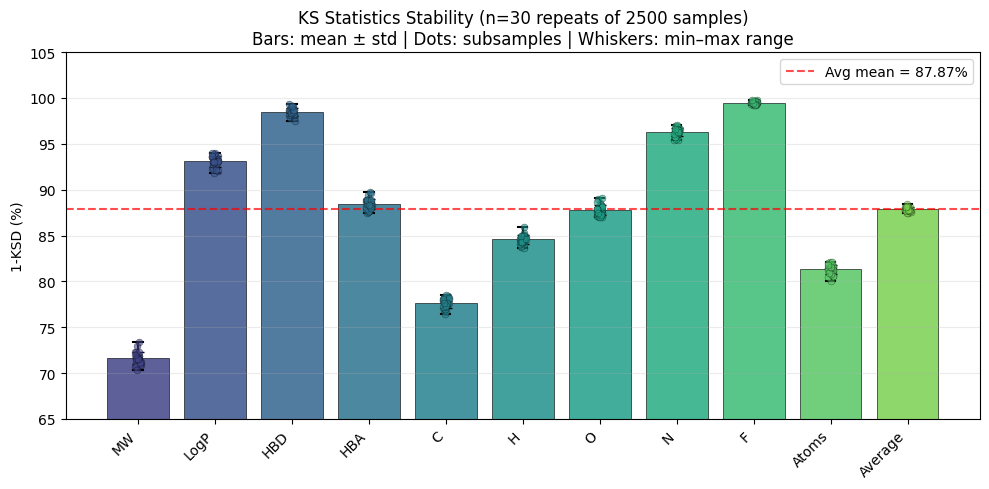


Stability summary (30 repeats, valid_only):
------------------------------------------------------------
        MW: 71.60% ± 0.65%  [min: 70.30%, max: 73.41%]
      LogP: 93.08% ± 0.55%  [min: 91.81%, max: 93.99%]
       HBD: 98.48% ± 0.43%  [min: 97.46%, max: 99.32%]
       HBA: 88.44% ± 0.57%  [min: 87.47%, max: 89.74%]
         C: 77.66% ± 0.56%  [min: 76.40%, max: 78.56%]
         H: 84.59% ± 0.47%  [min: 83.68%, max: 85.97%]
         O: 87.77% ± 0.56%  [min: 86.99%, max: 89.12%]
         N: 96.32% ± 0.45%  [min: 95.38%, max: 97.05%]
         F: 99.49% ± 0.14%  [min: 99.24%, max: 99.76%]
     Atoms: 81.32% ± 0.47%  [min: 80.09%, max: 82.15%]
   Average: 87.87% ± 0.22%  [min: 87.48%, max: 88.39%]


In [5]:
# Visualize stability analysis: KS statistics variance across subsample repeats
# Results from: results-stability-2500/ (multiple random 2500-subsets from 80K)

from pathlib import Path

STABILITY_DIR = Path("results-stability-2500")
STABILITY_DIR = Path("results-stability-10000")
MODE = "valid_only"  # or "all_samples"
METRIC_LABELS = {"mw": "MW", "logp": "LogP", "hbd": "HBD", "hba": "HBA", "C": "C", "H": "H", "O": "O", "N": "N", "F": "F", "atoms": "Atoms", "Average": "Average"}


def parse_ks_summary(filepath: Path) -> dict[str, float]:
    """Parse ks_statistics_summary.txt and return {metric: value}."""
    metrics = {}
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("=") or line.startswith("-") or "Metric" in line or "1-KSD" in line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    metrics[parts[0]] = float(parts[1])
                except ValueError:
                    continue
    return metrics


# Load all repeats
repeat_dirs = sorted(STABILITY_DIR.glob("repeat-*"), key=lambda p: int(p.name.split("-")[1]))
if not repeat_dirs:
    raise FileNotFoundError(f"No repeat-* folders in {STABILITY_DIR}")

data_by_repeat = []
for rdir in repeat_dirs:
    summary_path = rdir / MODE / "ks_statistics_summary.txt"
    if not summary_path.exists():
        print(f"Warning: {summary_path} not found, skipping")
        continue
    data_by_repeat.append(parse_ks_summary(summary_path))

# Aggregate: mean and std per metric
metrics = [m for m in data_by_repeat[0].keys()]
means = {}
stds = {}
for m in metrics:
    vals = [d[m] for d in data_by_repeat if m in d and d[m] is not None]
    means[m] = np.mean(vals)
    stds[m] = np.std(vals) if len(vals) > 1 else 0.0

# Plot bar chart with error bars + individual repeat values (scatter overlay shows spread)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics))
vals = [100 * means[m] for m in metrics]
errs = [100 * stds[m] for m in metrics]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(metrics)))
bars = ax.bar(x, vals, yerr=errs, capsize=4, color=colors, edgecolor="black", linewidth=0.5, alpha=0.85)

# Overlay individual repeat values as scatter points (jittered on x to show spread)
np.random.seed(42)
for i, m in enumerate(metrics):
    raw_vals = [100 * d[m] for d in data_by_repeat if m in d and d[m] is not None]
    jitter = 0.08 * (np.random.rand(len(raw_vals)) - 0.5)
    ax.scatter(np.full(len(raw_vals), i) + jitter, raw_vals, c=colors[i], s=25, alpha=0.6,
               edgecolors="black", linewidths=0.3, zorder=5)

# Min/max range whiskers: vertical line + small caps showing full spread
for i, m in enumerate(metrics):
    raw_vals = [100 * d[m] for d in data_by_repeat if m in d and d[m] is not None]
    if len(raw_vals) < 2:
        continue
    ymin, ymax = min(raw_vals), max(raw_vals)
    cap_w = 0.06
    ax.plot([i, i], [ymin, ymax], color="black", linewidth=1.5, zorder=4)
    ax.plot([i - cap_w, i + cap_w], [ymin, ymin], color="black", linewidth=1.5, zorder=4)
    ax.plot([i - cap_w, i + cap_w], [ymax, ymax], color="black", linewidth=1.5, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels([METRIC_LABELS.get(m, m) for m in metrics], rotation=45, ha="right")
ax.set_ylabel("1-KSD (%)")
ax.set_title(f"KS Statistics Stability (n={len(repeat_dirs)} repeats of 2500 samples)\nBars: mean ± std | Dots: subsamples | Whiskers: min–max range")
ax.axhline(y=100 * means.get("Average", 0), color="red", linestyle="--", alpha=0.7, label=f"Avg mean = {100*means.get('Average', 0):.2f}%")
ax.legend()
ax.grid(True, alpha=0.25, axis="y")
ax.set_ylim(65, 105)
plt.tight_layout()
plt.show()

# Print summary table (includes min/max to show full range)
print(f"\nStability summary ({len(repeat_dirs)} repeats, {MODE}):")
print("-" * 60)
for m in metrics:
    raw = [100 * d[m] for d in data_by_repeat if m in d and d[m] is not None]
    mn, mx = (min(raw), max(raw)) if raw else (float("nan"), float("nan"))
    print(f"  {METRIC_LABELS.get(m, m):>8}: {100*means[m]:.2f}% ± {100*stds[m]:.2f}%  [min: {mn:.2f}%, max: {mx:.2f}%]")

## Hydrogen reordering (original QM9 order vs nearest-heavy)

Preprocessed QM9 keeps **`original_atomic_symbols` / `original_pos`** in the raw Hugging Face order (heavy atoms in canonical SMILES order; hydrogens usually **after** all heavies). The main fields **`atomic_symbols` / `pos`** apply the reorder from `custom_datasets/qm9_hydrogen_order.py`: each H is placed **before** its **nearest** heavy atom (ties broken deterministically).

**Geometry is unchanged**—only the **permutation** of atoms changes. The **red polyline** connects atoms in **sequence order** (indices 0 → 1 → 2 → …), not necessarily along bonds. After reordering, consecutive indices tend to be **closer in 3D** because hydrogens sit next to their parent heavy in the list.

Run preprocessing **without** `--no_hydrogen_reorder` so `original_*` and the main fields differ. Earlier cells must define `qm9_dataset` (and ideally `max_atoms_for_plot` / `candidate_indices` for a compact example).

The following cell defines **`plot_sequence_path_3d`**, **`plot_hydrogen_reorder_comparison_figure`**, **`iter_hydrogen_reorder_sample_indices`**, and **`save_hydrogen_reorder_batch`**. Tune **`n_save`** (how many figures) and **`output_dir`**; files are written as ``qm9_hydrogen_reorder_{dataset_index:06d}.png`` (and `.pdf` when enabled).



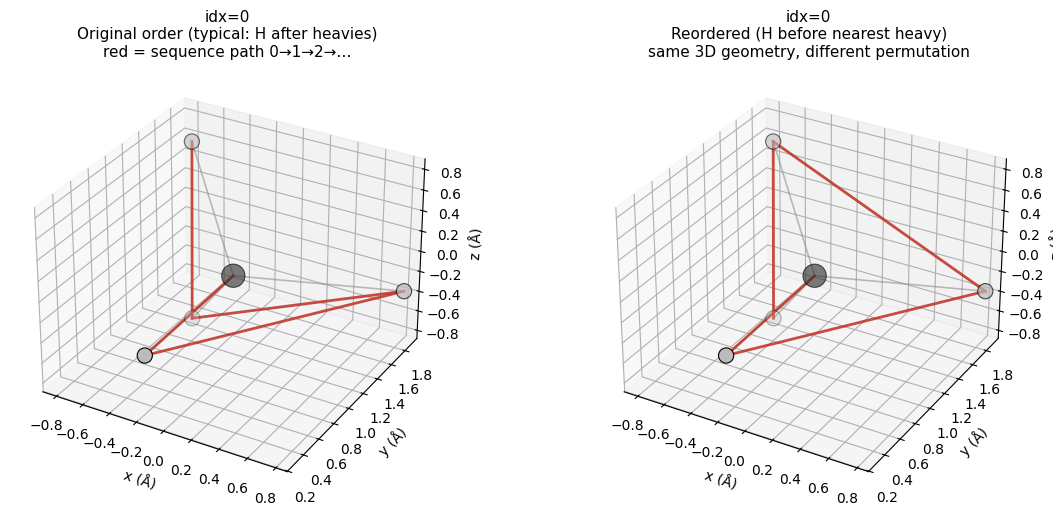

Wrote 24 comparisons under figures/qm9_hydrogen_reorder/
  idx=0: figures/qm9_hydrogen_reorder/qm9_hydrogen_reorder_000000.png
  idx=1: figures/qm9_hydrogen_reorder/qm9_hydrogen_reorder_000001.png
  idx=2: figures/qm9_hydrogen_reorder/qm9_hydrogen_reorder_000002.png
  idx=3: figures/qm9_hydrogen_reorder/qm9_hydrogen_reorder_000003.png
  idx=4: figures/qm9_hydrogen_reorder/qm9_hydrogen_reorder_000004.png
  idx=5: figures/qm9_hydrogen_reorder/qm9_hydrogen_reorder_000005.png
  idx=6: figures/qm9_hydrogen_reorder/qm9_hydrogen_reorder_000006.png
  idx=7: figures/qm9_hydrogen_reorder/qm9_hydrogen_reorder_000007.png
  ...


In [ ]:
from pathlib import Path

from visualize_dataset import _get_bonds_via_openbabel
from custom_datasets.qm9_hydrogen_order import reorder_hydrogens_nearest_heavy


def plot_sequence_path_3d(symbols, pos, ax, title, *, show_bonds=True):
    """Same 3D geometry; gray sticks = OpenBabel bonds; red = walk in list order 0→1→2→…"""
    symbols = list(symbols)
    pos = np.asarray(pos, dtype=float)
    n = len(symbols)
    colors = {
        "H": "#bbbbbb",
        "C": "#333333",
        "N": "#3050f8",
        "O": "#ff0d0d",
        "F": "#90e050",
    }
    atom_colors = [colors.get(s, "#ff69b4") for s in symbols]
    sizes = [120 if s == "H" else 280 for s in symbols]
    ax.scatter(
        pos[:, 0],
        pos[:, 1],
        pos[:, 2],
        s=sizes,
        c=atom_colors,
        edgecolor="black",
        linewidths=0.8,
        depthshade=True,
        zorder=3,
    )
    if show_bonds and n > 1:
        try:
            bonds = _get_bonds_via_openbabel(symbols, pos)
            for i, j in bonds:
                ax.plot(
                    [pos[i, 0], pos[j, 0]],
                    [pos[i, 1], pos[j, 1]],
                    [pos[i, 2], pos[j, 2]],
                    color="#888888",
                    linewidth=1.2,
                    alpha=0.55,
                    zorder=1,
                )
        except Exception:
            pass
    for t in range(n - 1):
        ax.plot(
            [pos[t, 0], pos[t + 1, 0]],
            [pos[t, 1], pos[t + 1, 1]],
            [pos[t, 2], pos[t + 1, 2]],
            color="#c0392b",
            linewidth=2.0,
            alpha=0.9,
            zorder=2,
        )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x (Å)")
    ax.set_ylabel("y (Å)")
    ax.set_zlabel("z (Å)")
    max_range = float(np.ptp(pos, axis=0).max()) / 2.0
    if max_range < 1e-6:
        max_range = 1.0
    mid = pos.mean(axis=0)
    ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
    ax.set_zlim(mid[2] - max_range, mid[2] + max_range)


def plot_hydrogen_reorder_comparison_figure(
    orig_sym,
    orig_pos,
    new_sym,
    new_pos,
    *,
    sample_idx=None,
    figsize=(12, 5.2),
):
    """Side-by-side 3D: original atom order vs reorder. Call ``plt.close(fig)`` after saving many."""
    fig = plt.figure(figsize=figsize)
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    t1 = "Original order (typical: H after heavies)\nred = sequence path 0→1→2→…"
    t2 = "Reordered (H before nearest heavy)\nsame 3D geometry, different permutation"
    if sample_idx is not None:
        t1 = f"idx={sample_idx}\n" + t1
        t2 = f"idx={sample_idx}\n" + t2
    plot_sequence_path_3d(orig_sym, orig_pos, ax1, t1)
    plot_sequence_path_3d(new_sym, new_pos, ax2, t2)
    plt.tight_layout()
    return fig


def iter_hydrogen_reorder_sample_indices(raw_dataset, *, max_atoms=12):
    """Yield indices of rows that have ``original_*`` and at most ``max_atoms`` atoms."""
    for i in range(len(raw_dataset)):
        row = raw_dataset[i]
        if "original_atomic_symbols" not in row:
            continue
        if len(row["atomic_symbols"]) > max_atoms:
            continue
        yield i


def save_hydrogen_reorder_batch(
    raw_dataset,
    *,
    output_dir="figures/qm9_hydrogen_reorder",
    max_atoms=12,
    num_images=20,
    dpi=200,
    verify_reorder=True,
    show_first=False,
):
    """
    Save many side-by-side comparison figures. Returns list of dicts with paths and metadata.

    Parameters
    ----------
    raw_dataset : HuggingFace Dataset
        Same object as ``qm9_dataset.qm9_dataset`` (must include ``original_*`` if preprocessed with reorder).
    output_dir : str or Path
        Subfolder created if missing; files named ``qm9_hydrogen_reorder_{idx:06d}.png``.
    max_atoms : int
        Only molecules with at most this many atoms.
    num_images : int
        Maximum number of figures to write.
    show_first : bool
        If True, ``plt.show()`` the first figure (then close it).
    """
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    saved = []
    for sample_idx in iter_hydrogen_reorder_sample_indices(raw_dataset, max_atoms=max_atoms):
        if len(saved) >= num_images:
            break
        row = raw_dataset[sample_idx]
        orig_sym = list(row["original_atomic_symbols"])
        orig_pos = np.asarray(row["original_pos"], dtype=float)
        new_sym = list(row["atomic_symbols"])
        new_pos = np.asarray(row["pos"], dtype=float)

        if verify_reorder:
            check_sym, check_pos = reorder_hydrogens_nearest_heavy(list(orig_sym), orig_pos.copy())
            if check_sym != new_sym or not np.allclose(check_pos, new_pos):
                print(
                    f"Warning idx={sample_idx}: recomputed reorder != stored fields. "
                    "Regenerate preprocess or disable verify_reorder."
                )

        fig = plot_hydrogen_reorder_comparison_figure(
            orig_sym, orig_pos, new_sym, new_pos, sample_idx=sample_idx
        )
        stem = out_dir / f"qm9_hydrogen_reorder_{sample_idx:06d}"
        fig.savefig(stem.with_suffix(".png"), dpi=dpi, bbox_inches="tight")
        if show_first and len(saved) == 0:
            plt.show()
        plt.close(fig)

        seq_o = "".join(orig_sym)
        seq_n = "".join(new_sym)
        saved.append(
            {
                "sample_idx": sample_idx,
                "png": str(stem.with_suffix(".png")),
                "seq_original": seq_o,
                "seq_reordered": seq_n,
            }
        )

    if not saved:
        raise RuntimeError(
            f"No qualifying rows (original_* present, len <= {max_atoms}). "
            "Regenerate data/qm9_preprocessed with hydrogen reordering."
        )
    return saved


# --- Run: requires ``qm9_dataset`` from earlier cells ---
max_n = globals().get("max_atoms_for_plot", 12)
n_save = 24  # change how many PNGs/PDFs to write

raw = qm9_dataset.qm9_dataset
batch_paths = save_hydrogen_reorder_batch(
    raw,
    output_dir="figures/qm9_hydrogen_reorder",
    max_atoms=max_n,
    num_images=n_save,
    save_pdf=True,
    verify_reorder=True,
    show_first=True,
)
print(f"Wrote {len(batch_paths)} comparisons under figures/qm9_hydrogen_reorder/")
for item in batch_paths[:8]:
    print(f"  idx={item['sample_idx']}: {item['png']}")
if len(batch_paths) > 8:
    print("  ...")
